# GSK_HepG2 ablation: metric vs training-data fraction

Pulls the single run from the `ablation_gsk_hepg2` wandb project, recovers the per-(fraction, model) rows from its history, and plots one line per model.

Each `wandb.log(row)` call in the ablation became a separate history step, so we read the full history with `scan_history()` and pivot on the `model` column ourselves.

In [3]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = "ablation_gsk_hepg2"
METRIC = "test_average_precision"  # swap for test_mcc, test_f1, test_average_precision, ...

api = wandb.Api()
runs = api.runs(f"{api.default_entity}/{PROJECT}")
# assert len(runs) == 1, f"expected a single run, found {len(runs)}"
run = [r for r in runs][0]
run.name, run.id

('morning-meadow-5', 'v5t1awds')

In [4]:
# Full, unsampled history -> one row per (fraction, model).
df = pd.DataFrame(run.scan_history())
df = df[["fraction", "model", "n_train", METRIC]].sort_values(["model", "fraction"])
df

,fraction,model,n_train,test_average_precision
0,0.1,chemprop,1055,0.227948
2,0.2,chemprop,2109,0.406060
4,0.3,chemprop,3164,0.650946
6,0.4,chemprop,4212,0.371677
8,0.5,chemprop,5272,0.514726
10,0.6,chemprop,6329,0.423875
12,0.7,chemprop,7384,0.478676
14,0.8,chemprop,8435,0.547646
16,0.9,chemprop,9493,0.528476
18,1.0,chemprop,10547,0.536711


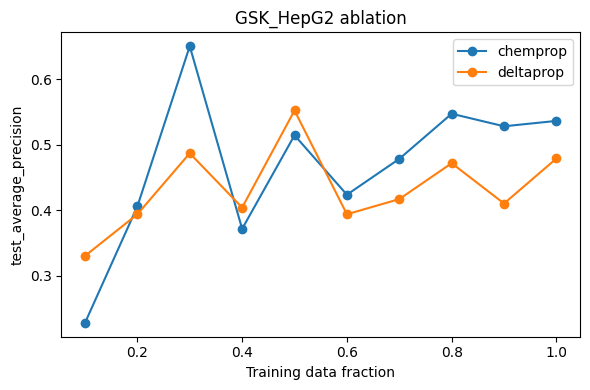

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

for model, g in df.groupby("model"):
    g = g.sort_values("fraction")
    ax.plot(g["fraction"], g[METRIC], marker="o", label=model)

ax.set_xlabel("Training data fraction")
ax.set_ylabel(METRIC)
ax.set_title("GSK_HepG2 ablation")
ax.legend()
fig.tight_layout()
fig.savefig("gsk_hepg2_ablation.png", dpi=150)
plt.show()